In [1]:
# Imports and figure-wide font setup
import os
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
from scipy.signal import butter, sosfiltfilt
from pathlib import Path
from matplotlib.patches import Patch

# Prefer Helvetica/Arial while keeping a portable sans-serif fallback.
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Helvetica', 'Arial', 'DejaVu Sans'],
    'font.size': 30,
    'axes.labelsize': 30,
    'axes.titlesize': 30,
    'xtick.labelsize': 30,
    'ytick.labelsize': 30,
    'legend.fontsize': 30,
    'figure.titlesize': 30,
    'axes.unicode_minus': False,
})
print('Libraries imported and font styling configured.')

Libraries imported and font styling configured.


In [2]:
# Constants
FULL_YEARS = np.arange(1981, 2026)
ANALYSIS_START = '1980-12-01'
ANALYSIS_END = '2025-02-28'
RUNNING_CORRELATION_WINDOW = 15
INDEX_LOWPASS_YEARS = 13

TARGET_BOX = {
    'lon_min': 95.0,
    'lon_max': 125.0,
    'lat_min': -6.0,
    'lat_max': 2.0,
}

RAINFALL_PATH = Path('/Users/rizzie/ClimateData/mswep-monthly/mswep_monthly_197903_202608.nc').resolve()
NINO34_PATH = Path('/Users/rizzie/ClimateData/index-monthly/nino34.anom.csv').resolve()
NINO34_COLUMN = '   Nino Anom 3.4 Index  using ersstv5 from CPC  missing value -99.99 https://psl.noaa.gov/data/timeseries/month/'

CLIMATE_INDEX_DIR = Path('/Users/rizzie/ClimateData/climate_index')
IPO_PATH = CLIMATE_INDEX_DIR / 'IPO' / 'tpi.timeseries.ersstv5.data.txt'
PDO_PATH = CLIMATE_INDEX_DIR / 'PDO' / 'pdo.data.txt'
AMO_PATH = CLIMATE_INDEX_DIR / 'AMO' / 'amo_monthly.txt'
AAO_PATH = CLIMATE_INDEX_DIR / 'AAO' / 'AAO_monthly.aao.index.b79.current.ascii'

MISSING_FLAGS = [-99, -99.9, -99.99, -999, -999.0, -9999, -9999.0, 99.99]
DEEP_BLUE = '#000080'
INDEX_COLORS = {
    'ipo': '#008C95',
    'pdo': '#D97706',
    'amo': '#7B61A8',
    'aao_sam': '#2E8B57',
}
print('Constants defined.')


Constants defined.


In [3]:
# Helper functions for data processing
def canonicalize_grid_coordinates(obj):
    rename_map = {}
    if 'valid_time' in obj.coords or 'valid_time' in obj.dims:
        rename_map['valid_time'] = 'time'
    if 'latitude' in obj.coords or 'latitude' in obj.dims:
        rename_map['latitude'] = 'lat'
    if 'longitude' in obj.coords or 'longitude' in obj.dims:
        rename_map['longitude'] = 'lon'
    if rename_map:
        obj = obj.rename(rename_map)
    if 'lon' in obj.coords:
        obj = obj.assign_coords(lon=(obj.lon % 360)).sortby('lon')
    if 'lat' in obj.coords:
        lat_values = np.asarray(obj['lat'].values)
        if lat_values.size > 1 and lat_values[0] < lat_values[-1]:
            obj = obj.sortby('lat', ascending=False)
    return obj


def select_target_box(da, box):
    lon_slice = slice(box['lon_min'], box['lon_max'])
    lat_values = np.asarray(da['lat'].values)
    if lat_values[0] > lat_values[-1]:
        lat_slice = slice(box['lat_max'], box['lat_min'])
    else:
        lat_slice = slice(box['lat_min'], box['lat_max'])
    return da.sel(lon=lon_slice, lat=lat_slice)


def build_djf_yearly_box_mean(da, box, name='rainfall'):
    da = canonicalize_grid_coordinates(da)
    da = da.sel(time=slice(ANALYSIS_START, ANALYSIS_END))
    da = select_target_box(da, box)
    da = da.sel(time=da.time.dt.month.isin((12, 1, 2)))
    djf_year = xr.where(da.time.dt.month == 12, da.time.dt.year + 1, da.time.dt.year)
    da = da.assign_coords(djf_year=('time', djf_year.data))
    da = da.sel(time=da.djf_year.isin(FULL_YEARS))
    return da.mean(dim=('lat', 'lon')).groupby('djf_year').mean('time').rename(name)


def to_pandas_series(da):
    out = pd.Series(da.values, index=da['djf_year'].values, name=da.name, dtype='float64')
    out.index.name = 'djf_year'
    return out.dropna()


def build_nino34_djf_series():
    df = pd.read_csv(NINO34_PATH, usecols=['Date', NINO34_COLUMN], parse_dates=['Date'])
    df = df.set_index('Date')
    df[NINO34_COLUMN] = df[NINO34_COLUMN].replace(MISSING_FLAGS, np.nan)
    df = df.loc[ANALYSIS_START:ANALYSIS_END]
    df = df[df.index.month.isin((12, 1, 2))].copy()
    df['djf_year'] = df.index.year + (df.index.month == 12).astype('int8')
    df = df[df['djf_year'].isin(FULL_YEARS)].copy()
    series = df.groupby('djf_year')[NINO34_COLUMN].mean()
    out = pd.Series(series.to_numpy(), index=series.index.to_numpy(), name='nino34', dtype='float64')
    out.index.name = 'djf_year'
    return out.dropna()


def load_monthly_table_index(path, skiprows, name, missing_flags=MISSING_FLAGS):
    records = {}
    with open(path) as file:
        lines = file.readlines()[skiprows:]
    for line in lines:
        parts = line.split()
        if len(parts) < 13:
            continue
        try:
            year = int(float(parts[0]))
            values = [float(value) for value in parts[1:13]]
        except ValueError:
            continue
        for month, value in enumerate(values, start=1):
            records[pd.Timestamp(year=year, month=month, day=1)] = value
    monthly_raw = pd.Series(records, name=name, dtype='float64').sort_index()
    return monthly_raw.replace(missing_flags, np.nan)


def load_year_month_value_index(path, name, missing_flags=MISSING_FLAGS):
    df = pd.read_csv(path, sep=r'\s+', header=None, names=['year', 'month', 'value'])
    index = pd.to_datetime(dict(year=df['year'], month=df['month'], day=1))
    monthly_raw = pd.Series(df['value'].to_numpy(), index=index, name=name, dtype='float64').sort_index()
    return monthly_raw.replace(missing_flags, np.nan)


def monthly_year_positions(monthly_raw):
    return monthly_raw.index.year + (monthly_raw.index.month - 0.5) / 12


def lowpass_filter_monthly_index(monthly_raw, years=INDEX_LOWPASS_YEARS, order=4):
    """Return an unstandardized, zero-phase Butterworth low-pass index."""
    cutoff_cycles_per_month = 1 / (years * 12)
    normalized_cutoff = cutoff_cycles_per_month / 0.5  # 0.5 cycles/month is Nyquist.
    sos = butter(order, normalized_cutoff, btype='lowpass', output='sos')
    full_monthly_index = pd.date_range(monthly_raw.index.min(), monthly_raw.index.max(), freq='MS')
    monthly_raw = monthly_raw.reindex(full_monthly_index)
    valid_start = monthly_raw.first_valid_index()
    valid_end = monthly_raw.last_valid_index()
    filter_input = monthly_raw.loc[valid_start:valid_end].interpolate(method='time', limit_area='inside')
    if filter_input.isna().any():
        raise ValueError('The low-pass filter requires data at both ends of the index series.')
    filtered_values = sosfiltfilt(sos, filter_input.to_numpy(dtype='float64'))
    filtered = pd.Series(np.nan, index=monthly_raw.index, name=monthly_raw.name)
    filtered.loc[filter_input.index] = filtered_values
    return filtered


def build_djf_yearly_monthly_index(monthly_index, name):
    """Average Dec–Feb monthly values into DJF years 1981–2025."""
    monthly_index = monthly_index.loc[ANALYSIS_START:ANALYSIS_END]
    monthly_index = monthly_index[monthly_index.index.month.isin((12, 1, 2))]
    djf_year = monthly_index.index.year + (monthly_index.index.month == 12).astype('int8')
    djf_index = monthly_index.groupby(djf_year).mean()
    djf_index = djf_index.reindex(FULL_YEARS).rename(name)
    djf_index.index.name = 'djf_year'
    return djf_index


def centered_running_corr_minvalid(series, reference, window, min_frac=0.8):
    pair = pd.concat([series, reference], axis=1, join='inner')
    pair.columns = ['a', 'b']
    if pair.empty:
        return pd.Series(dtype='float64')
    full_index = np.arange(pair.index.min(), pair.index.max() + 1)
    pair = pair.reindex(full_index)
    min_periods = int(np.ceil(window * min_frac))
    valid = pair.notna().all(axis=1)
    valid_count = valid.rolling(window=window, center=True, min_periods=1).sum()
    correlation = pair['a'].rolling(window=window, center=True, min_periods=min_periods).corr(pair['b'])
    correlation = correlation.where(valid_count >= min_periods)
    correlation.index.name = 'djf_year'
    return correlation


print('Helper functions defined.')

Helper functions defined.


In [4]:
# Plotting helpers
def style_correlation_axis(ax, title):
    ax.axhline(0.0, color='0.35', linewidth=1.0, linestyle='--', zorder=1)
    ax.set_ylim(-1.0, 1.0)
    ax.set_yticks([-1.0, -0.5, 0.0, 0.5, 1.0])
    ax.set_xlim(FULL_YEARS.min(), FULL_YEARS.max())
    ax.set_xticks(np.arange(1985, 2021, 5))
    ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.4, zorder=0)
    ax.set_xlabel('Year', fontsize=30, fontweight='normal', fontname='Helvetica')
    ax.set_ylabel('ENSO–rainfall correlation', fontsize=30, color='black',
                  fontweight='normal', fontname='Helvetica')
    ax.tick_params(axis='y', labelcolor='black', labelsize=30)
    ax.tick_params(axis='x', labelsize=30)
    for tick_label in ax.get_yticklabels() + ax.get_xticklabels():
        tick_label.set_fontname('Helvetica')
        tick_label.set_fontsize(30)
        tick_label.set_fontweight('normal')
    ax.set_title(title, fontsize=30, fontweight='normal', loc='left', fontname='Helvetica')


def plot_enso_rainfall_correlation(ax, correlation):
    line, = ax.plot(correlation.index, correlation.values, linewidth=4.5,
                    color='black', linestyle='-',
                    label='ENSO-Rainfall 15yr corr.', zorder=4)
    return line


def plot_djf_index_with_lowpass(ax, raw_djf, filtered_djf, axis_label, raw_legend_label, filtered_legend_label, color):
    ax2 = ax.twinx()
    raw_line, = ax2.plot(raw_djf.index, raw_djf.values,
                         linewidth=1.2, color=color, alpha=0.65, linestyle='-',
                         label=raw_legend_label, zorder=2)
    filtered_line, = ax2.plot(filtered_djf.index, filtered_djf.values,
                              linewidth=4.0, color=color, linestyle='-',
                              label=filtered_legend_label, zorder=3)
    ax2.set_ylabel(axis_label, fontsize=30, color=color, fontweight='normal', fontname='Helvetica')
    ax2.tick_params(axis='y', labelcolor=color, labelsize=30)
    for tick_label in ax2.get_yticklabels():
        tick_label.set_fontname('Helvetica')
        tick_label.set_fontsize(30)
        tick_label.set_fontweight('normal')
    return raw_line, filtered_line


def plot_monthly_index_with_lowpass(ax, raw_monthly, filtered_monthly, axis_label, raw_legend_label, filtered_legend_label, color):
    ax2 = ax.twinx()
    raw_line, = ax2.plot(monthly_year_positions(raw_monthly), raw_monthly.values,
                         linewidth=1.2, color=color, alpha=0.65, linestyle='-',
                         label=raw_legend_label, zorder=2)
    filtered_line, = ax2.plot(monthly_year_positions(filtered_monthly), filtered_monthly.values,
                              linewidth=4.0, color=color, linestyle='-',
                              label=filtered_legend_label, zorder=3)
    ax2.set_ylabel(axis_label, fontsize=30, color=color, fontweight='normal', fontname='Helvetica')
    ax2.tick_params(axis='y', labelcolor=color, labelsize=30)
    for tick_label in ax2.get_yticklabels():
        tick_label.set_fontname('Helvetica')
        tick_label.set_fontsize(30)
        tick_label.set_fontweight('normal')
    return raw_line, filtered_line


def add_panel_legend(ax, correlation_line, raw_index_line, filtered_index_line):
    legend = ax.legend(handles=[correlation_line, raw_index_line, filtered_index_line], frameon=True, loc='upper left',
                       fontsize=24, facecolor='white', edgecolor='0.35', framealpha=0.95)
    for text in legend.get_texts():
        text.set_fontname('Helvetica')
        text.set_fontsize(24)
        text.set_fontweight('normal')
    return legend


print('Plotting functions defined.')

Plotting functions defined.


Saved full-record raw and Butterworth-filtered monthly indices to /Users/rizzie/Work/PaperENSO/Scripts_v2/Fig8/fig8_indices_monthly.csv
Saved 1981–2025 raw and Butterworth-filtered DJF indices to /Users/rizzie/Work/PaperENSO/Scripts_v2/Fig8/fig8_indices_djf.csv


Successfully saved 300 dpi DJF PNG to /Users/rizzie/Work/PaperENSO/Scripts_v2/Fig8/fig8_decadal_association.png


Successfully saved 300 dpi monthly PNG to /Users/rizzie/Work/PaperENSO/Scripts_v2/Fig8/fig8_decadal_association_monthly.png


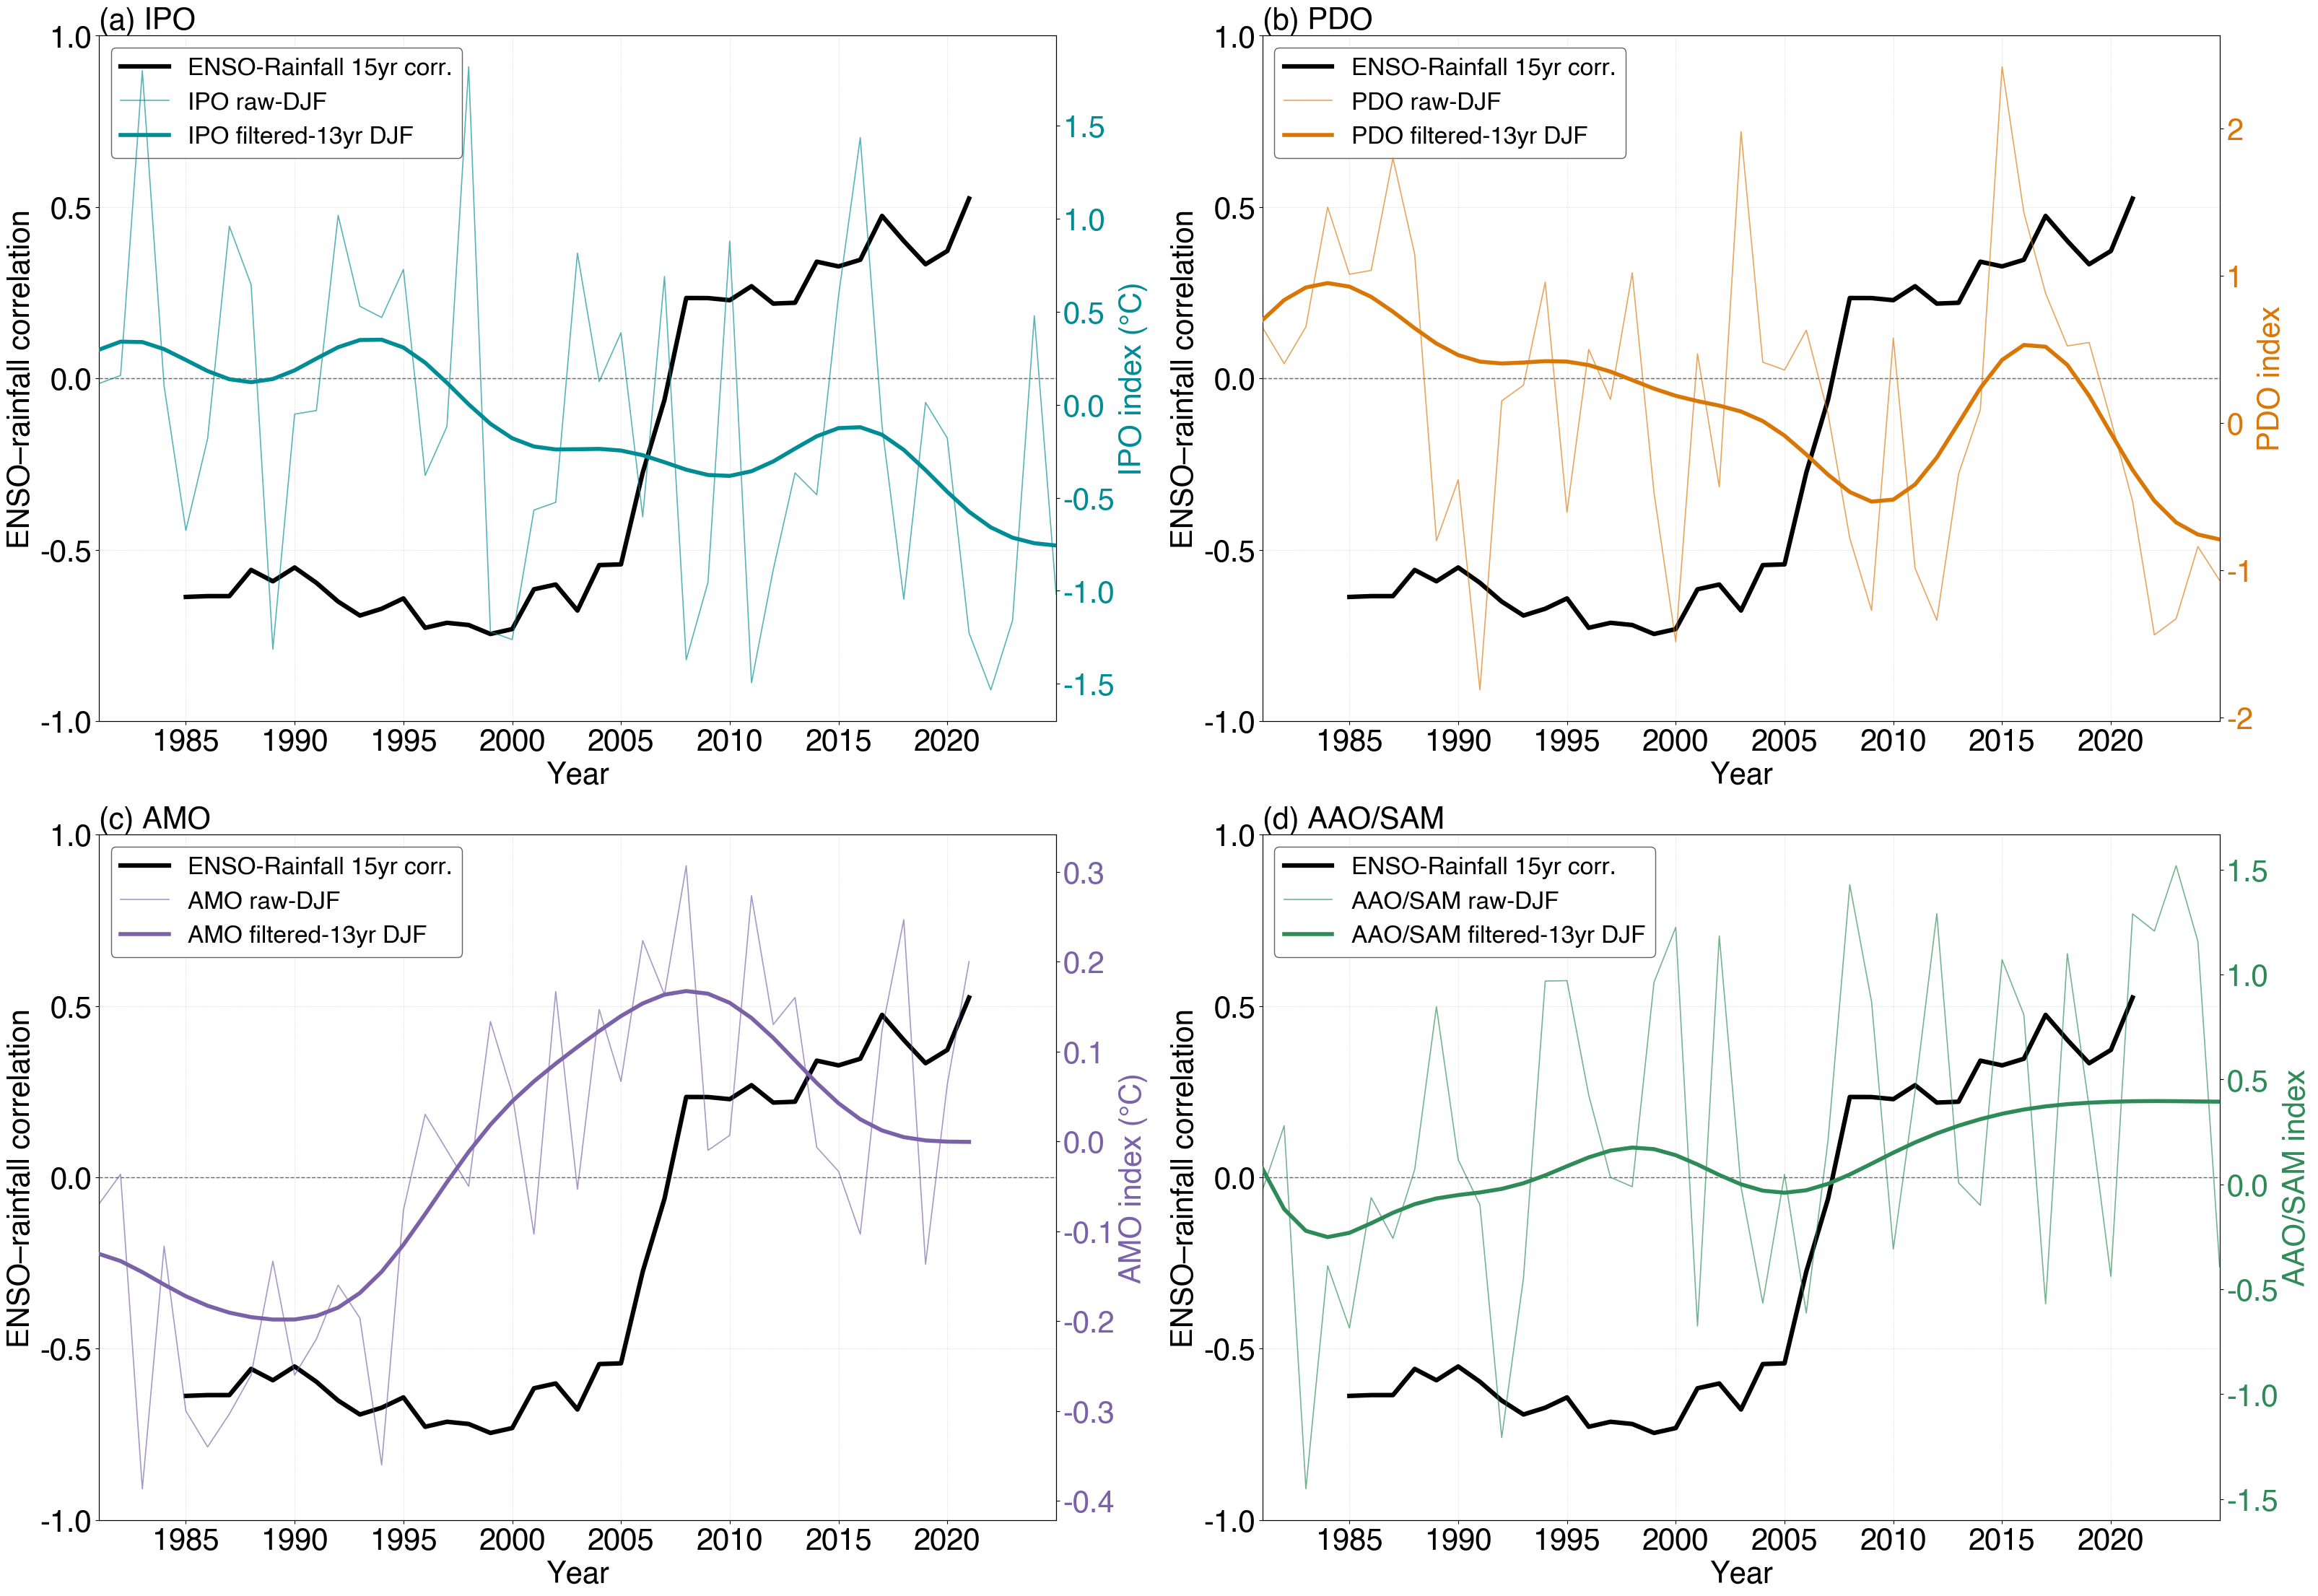

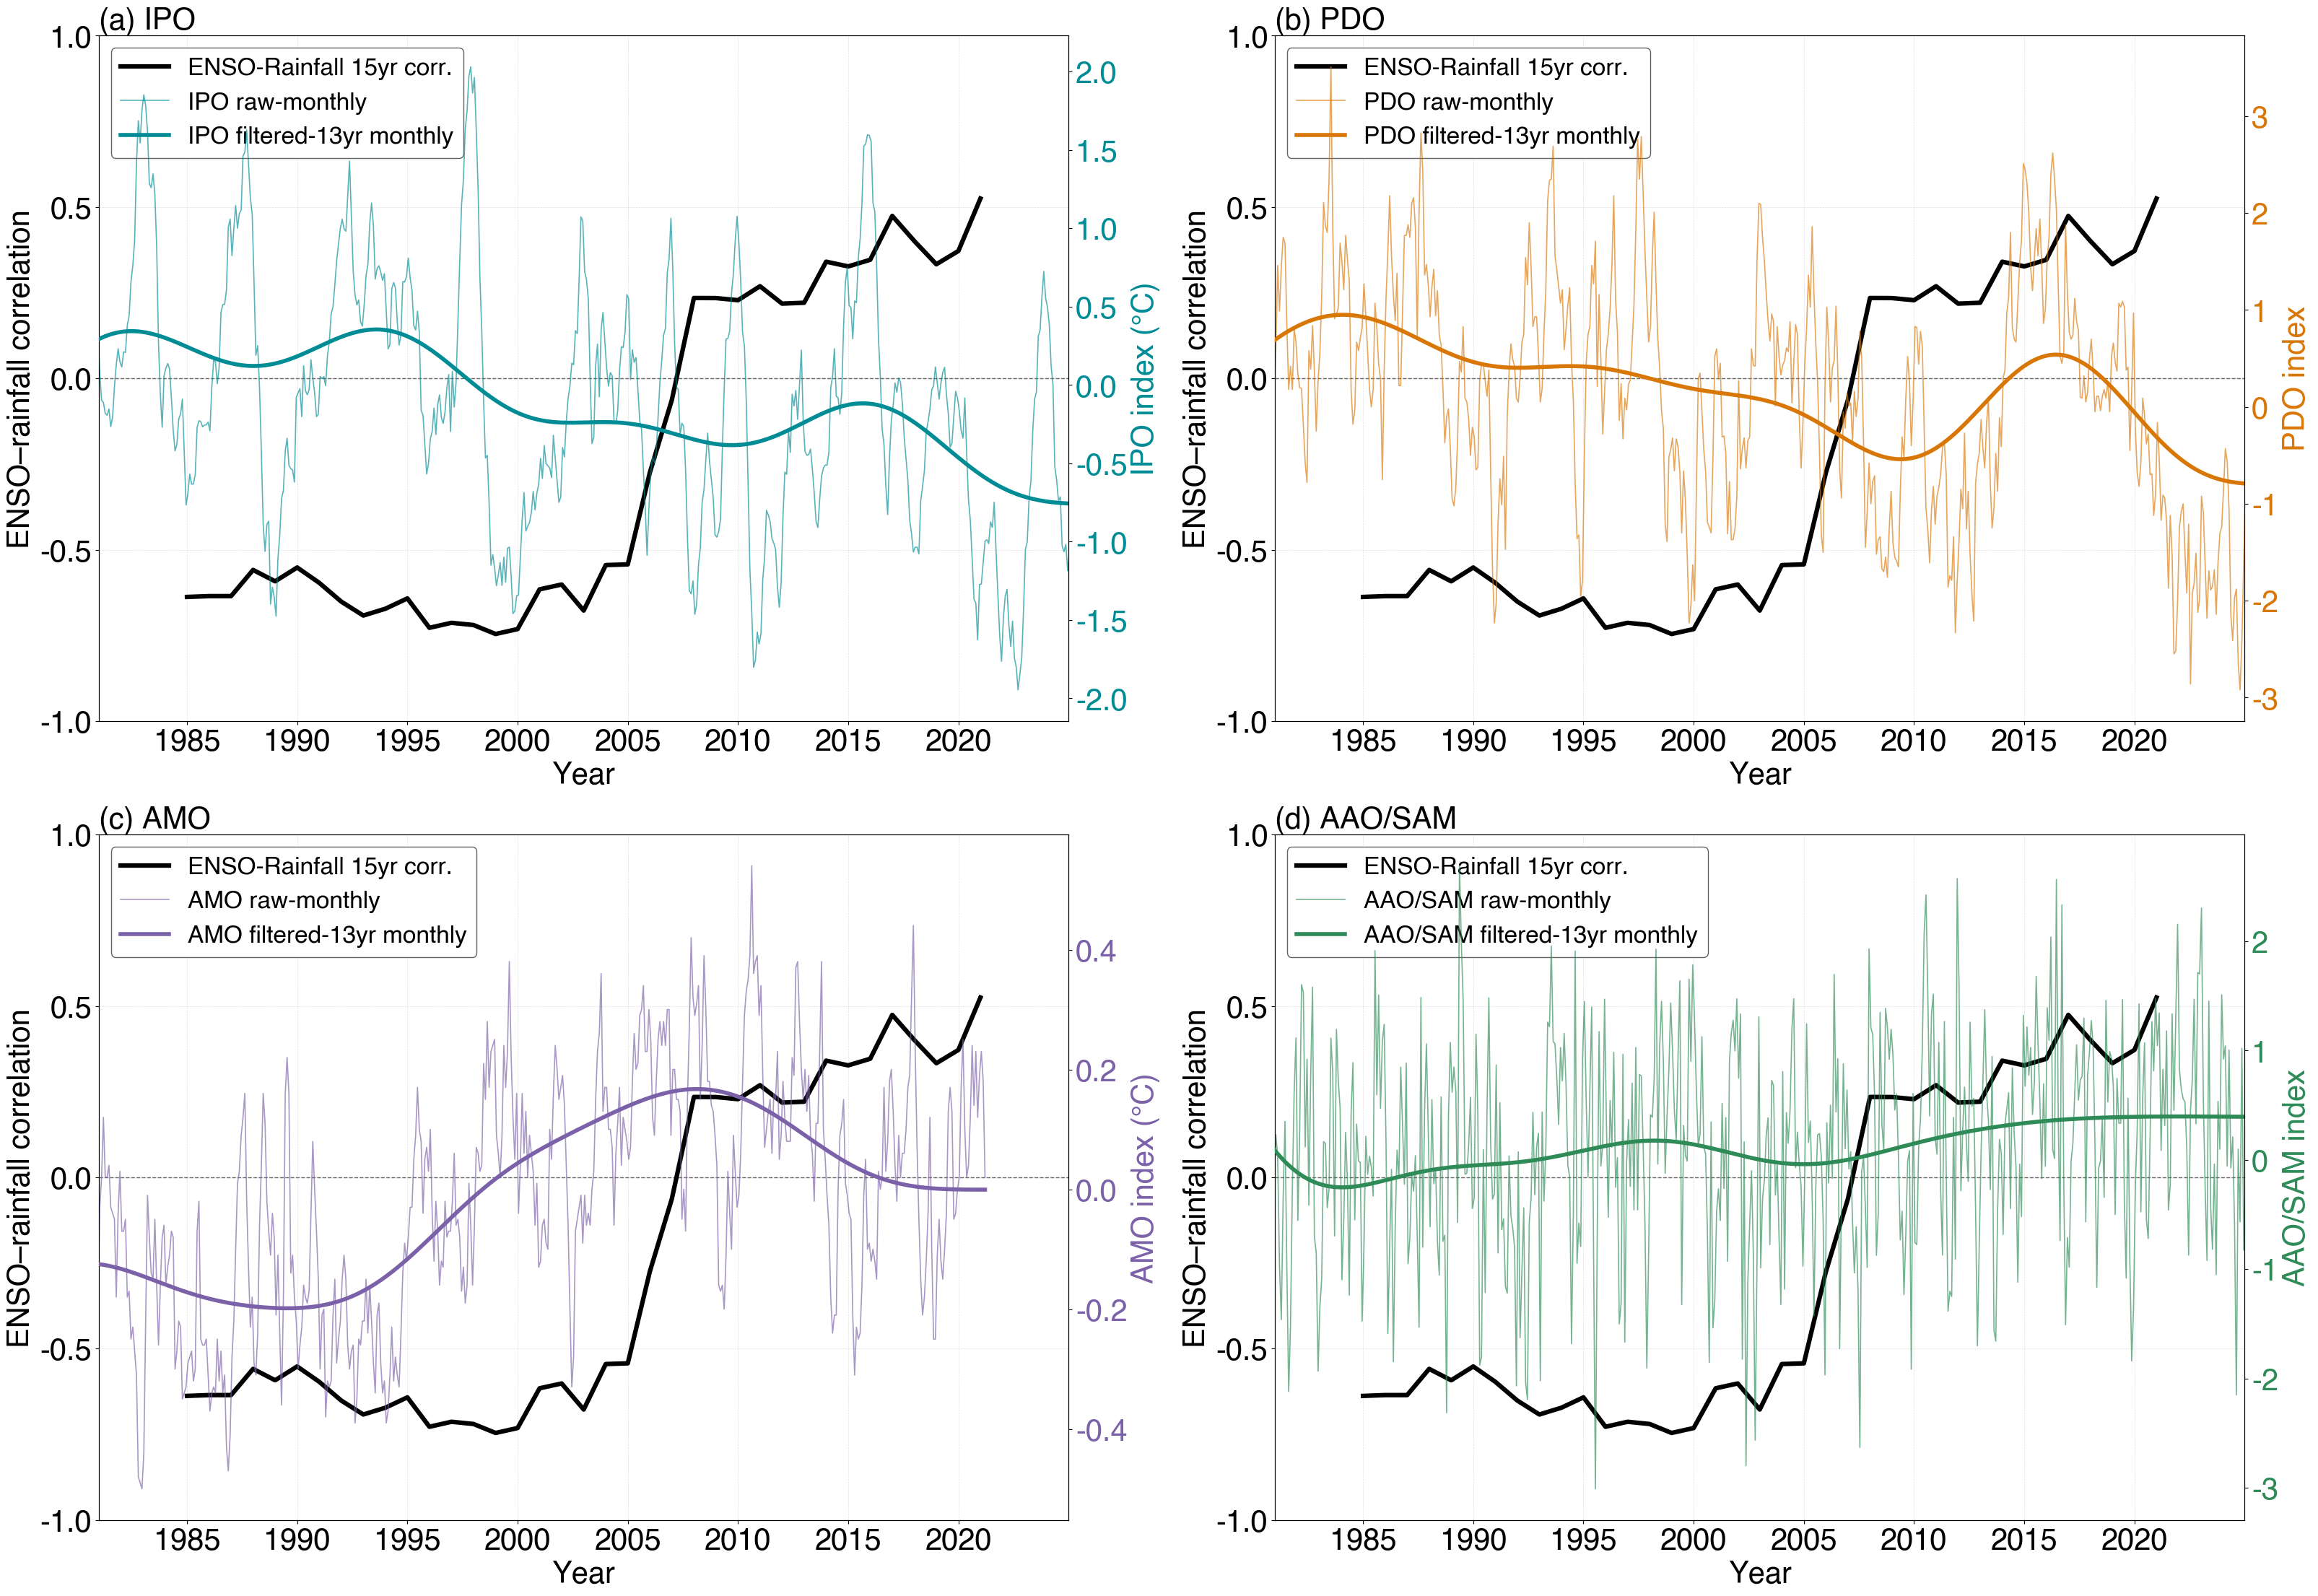

In [5]:
# Main execution and plotting
rain_ds = xr.open_dataset(RAINFALL_PATH)
rainfall = build_djf_yearly_box_mean(rain_ds['precipitation'], TARGET_BOX, name='rainfall')
rainfall_series = to_pandas_series(rainfall)
nino34_djf = build_nino34_djf_series()
overlap = pd.concat([rainfall_series, nino34_djf], axis=1, join='inner').dropna()
overlap.columns = ['rainfall', 'nino34']
nino_corr = centered_running_corr_minvalid(
    overlap['rainfall'], overlap['nino34'], RUNNING_CORRELATION_WINDOW
)

index_specs = [
    {
        'title': '(a) IPO', 'axis_label': 'IPO index (°C)',
        'raw_legend_label': 'IPO raw-DJF', 'filtered_legend_label': 'IPO filtered-13yr DJF',
        'raw_monthly_legend_label': 'IPO raw-monthly', 'filtered_monthly_legend_label': 'IPO filtered-13yr monthly',
        'csv_column': 'ipo',
        'color': INDEX_COLORS['ipo'],
        'loader': lambda: load_monthly_table_index(IPO_PATH, skiprows=1, name='ipo_monthly_raw'),
    },
    {
        'title': '(b) PDO', 'axis_label': 'PDO index',
        'raw_legend_label': 'PDO raw-DJF', 'filtered_legend_label': 'PDO filtered-13yr DJF',
        'raw_monthly_legend_label': 'PDO raw-monthly', 'filtered_monthly_legend_label': 'PDO filtered-13yr monthly',
        'csv_column': 'pdo',
        'color': INDEX_COLORS['pdo'],
        'loader': lambda: load_monthly_table_index(PDO_PATH, skiprows=1, name='pdo_monthly_raw'),
    },
    {
        'title': '(c) AMO', 'axis_label': 'AMO index (°C)',
        'raw_legend_label': 'AMO raw-DJF', 'filtered_legend_label': 'AMO filtered-13yr DJF',
        'raw_monthly_legend_label': 'AMO raw-monthly', 'filtered_monthly_legend_label': 'AMO filtered-13yr monthly',
        'csv_column': 'amo',
        'color': INDEX_COLORS['amo'],
        'loader': lambda: load_monthly_table_index(AMO_PATH, skiprows=1, name='amo_monthly_raw'),
    },
    {
        'title': '(d) AAO/SAM', 'axis_label': 'AAO/SAM index',
        'raw_legend_label': 'AAO/SAM raw-DJF', 'filtered_legend_label': 'AAO/SAM filtered-13yr DJF',
        'raw_monthly_legend_label': 'AAO/SAM raw-monthly', 'filtered_monthly_legend_label': 'AAO/SAM filtered-13yr monthly',
        'csv_column': 'aao_sam',
        'color': INDEX_COLORS['aao_sam'],
        'loader': lambda: load_year_month_value_index(AAO_PATH, name='aao_sam_monthly_raw'),
    },
]

monthly_export = {}
djf_export = {}
index_data = {}
djf_indices = {}
for spec in index_specs:
    monthly_raw_full = spec['loader']()
    monthly_filtered_full = lowpass_filter_monthly_index(monthly_raw_full)
    monthly_raw_analysis = monthly_raw_full.loc[ANALYSIS_START:ANALYSIS_END]
    monthly_filtered_analysis = monthly_filtered_full.loc[ANALYSIS_START:ANALYSIS_END]
    monthly_export[f"{spec['csv_column']}_raw"] = monthly_raw_full
    monthly_export[f"{spec['csv_column']}_filtered"] = monthly_filtered_full
    djf_indices[spec['title']] = {
        'raw': build_djf_yearly_monthly_index(monthly_raw_full, name='raw_djf'),
        'filtered': build_djf_yearly_monthly_index(monthly_filtered_full, name='filtered_djf'),
    }
    djf_export[f"{spec['csv_column']}_raw_djf"] = djf_indices[spec['title']]['raw']
    djf_export[f"{spec['csv_column']}_filtered_djf"] = djf_indices[spec['title']]['filtered']
    index_data[spec['title']] = {
        'raw_monthly': monthly_raw_analysis,
        'filtered_monthly': monthly_filtered_analysis,
    }

output_dir = Path('/Users/rizzie/Work/PaperENSO/Scripts_v2/Fig8')
output_dir.mkdir(parents=True, exist_ok=True)
monthly_csv_path = output_dir / 'fig8_indices_monthly.csv'
djf_csv_path = output_dir / 'fig8_indices_djf.csv'
pd.concat(monthly_export, axis=1).to_csv(monthly_csv_path, index_label='date')
pd.concat(djf_export, axis=1).to_csv(djf_csv_path, index_label='djf_year')
print(f'Saved full-record raw and Butterworth-filtered monthly indices to {monthly_csv_path}')
print(f'Saved 1981–2025 raw and Butterworth-filtered DJF indices to {djf_csv_path}')

fig, axes = plt.subplots(2, 2, figsize=(32, 22), constrained_layout=True)
for ax, spec in zip(axes.flat, index_specs):
    correlation_line = plot_enso_rainfall_correlation(ax, nino_corr)
    style_correlation_axis(ax, spec['title'])
    raw_index_line, filtered_index_line = plot_djf_index_with_lowpass(
        ax, djf_indices[spec['title']]['raw'], djf_indices[spec['title']]['filtered'],
        spec['axis_label'], spec['raw_legend_label'], spec['filtered_legend_label'], spec['color']
    )
    add_panel_legend(ax, correlation_line, raw_index_line, filtered_index_line)

png_path = output_dir / 'fig8_decadal_association.png'
fig.savefig(png_path, dpi=300, bbox_inches='tight')
print(f'Successfully saved 300 dpi DJF PNG to {png_path}')

fig_monthly, axes_monthly = plt.subplots(2, 2, figsize=(32, 22), constrained_layout=True)
for ax, spec in zip(axes_monthly.flat, index_specs):
    correlation_line = plot_enso_rainfall_correlation(ax, nino_corr)
    style_correlation_axis(ax, spec['title'])
    raw_index_line, filtered_index_line = plot_monthly_index_with_lowpass(
        ax, index_data[spec['title']]['raw_monthly'], index_data[spec['title']]['filtered_monthly'],
        spec['axis_label'], spec['raw_monthly_legend_label'],
        spec['filtered_monthly_legend_label'], spec['color']
    )
    add_panel_legend(ax, correlation_line, raw_index_line, filtered_index_line)

monthly_png_path = output_dir / 'fig8_decadal_association_monthly.png'
fig_monthly.savefig(monthly_png_path, dpi=300, bbox_inches='tight')
print(f'Successfully saved 300 dpi monthly PNG to {monthly_png_path}')
plt.show()

## Revision summary

- Loaded the entire available monthly record for each index and applied the unstandardized, zero-phase fourth-order Butterworth filter before selecting the 1981–2025 DJF period.
- Produced parallel all-month and DJF-mean panels, each comparing raw and Butterworth-filtered index values with the 15-year ENSO–rainfall running correlation.
- Saved full-record raw and filtered monthly indices in `fig7_indices_monthly.csv` and 1981–2025 raw-DJF and filtered-DJF indices in `fig7_indices_djf.csv`.
